# 企业RAG知识库系统 — PDF多模态文档摄取

## 整体流程（多模态版）

```
PDF文件
  │
  ▼
内容类型检测（PyMuPDF）
  │
  ├── 文字块 ──────────────► 深度文本提取（保留字体/标题层级/格式）
  │                              │
  ├── 嵌入图片 ───────────► 图片提取 + 元数据记录（可接VLM生成描述）
  │                              │
  ├── 表格 ────────────────► pdfplumber表格识别 → Markdown格式转换
  │                              │
  └── 扫描页面 ──────────► OCR文字识别（easyocr / pytesseract）
                                 │
                                 ▼
                      多模态内容统一标记（content_type 元数据）
                                 │
                                 ▼
                      文本分块（各类型独立策略：文字切分/表格保整/图片保整）
                                 │
                                 ▼
                      HuggingFace Embeddings（向量化）
                                 │
                                 ▼
                      ChromaDB（持久化存储，含content_type元数据）
                                 │
                                 ▼
                      Retriever + Cross-Encoder（召回 + 精排）
```

## 各模态处理对比

| 内容类型 | 检测工具 | 提取工具 | RAG索引策略 |
|---------|---------|---------|------------|
| 普通文字 | PyMuPDF | `page.get_text("dict")` | 分块后向量化 |
| 标题/结构 | PyMuPDF | 字体大小+粗体判断 | 保留层级，优先分块边界 |
| 嵌入图片 | PyMuPDF | `page.get_images()` | 元数据描述 + 可选VLM描述 |
| 数据表格 | pdfplumber | `page.extract_tables()` | 整体保留为Markdown chunk |
| 扫描页面 | 字符数检测 | easyocr / pytesseract | OCR后按文字处理 |


## Step 0：安装依赖

In [ ]:
# 技术栈锁定：Saanw 项目（2024年4月-7月）历史版本
%pip install -q \
    "pymupdf==1.23.8" \
    "pdfplumber==0.10.3" \
    "pypdf==4.2.0" \
    "reportlab==4.1.0" \
    "Pillow==10.1.0" \
    "langchain==0.1.4" \
    "langchain-community==0.0.20" \
    "langchain-text-splitters==0.0.1" \
    "langchain-milvus==0.1.1" \
    "langchain-huggingface==0.0.1" \
    "sentence-transformers==2.7.0" \
    "pymilvus==2.3.7" \
    "numpy==1.26.4" \
    "python-dotenv==1.0.0" \
    "fastapi==0.110.0" \
    "pydantic==2.4.2" \
    "uvicorn==0.24.0" \
    "redis==5.0.1" \
    "elasticsearch==8.12.0"

import sys
print(f"Python: {sys.version}")
print("依赖安装完成")
print()
print("技术栈版本（Saanw 2024）:")
versions = {
    "pymupdf":                  "1.23.8  (2024)",
    "pdfplumber":               "0.10.3  (2024)",
    "pypdf":                    "4.2.0   (2024)",
    "Pillow":                   "10.1.0  (2024)",
    "reportlab":                "4.1.0   (2024)",
    "langchain":                "0.1.4   (2024)",
    "langchain-community":      "0.0.20  (2024)",
    "langchain-text-splitters": "0.0.1   (2024)",
    "langchain-milvus":         "0.1.1   (2024)",
    "langchain-huggingface":    "0.0.1   (2024)",
    "sentence-transformers":    "2.7.0   (2024)",
    "pymilvus":                 "2.3.7   (2024)",
    "fastapi":                  "0.110.0 (2024)",
    "pydantic":                 "2.4.2   (2024)",
    "uvicorn":                  "0.24.0  (2024)",
    "redis":                    "5.0.1   (2024)",
    "elasticsearch":            "8.12.0  (2024)",
}
for pkg, ver in versions.items():
    print(f"  {pkg:<28} {ver}")


Note: you may need to restart the kernel to use updated packages.
Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
依赖安装完成

技术栈版本（2024年4–7月）:
  pymupdf                      1.24.9  (2024-07)
  pdfplumber                   0.10.4  (2024-04)
  pypdf                        4.2.0   (2024-04)
  Pillow                       10.3.0  (2024-04)
  reportlab                    4.1.0   (2024-04)
  langchain                    0.2.5   (2024-06)
  langchain-text-splitters     0.2.1   (2024-05)
  langchain-community          0.2.5   (2024-06)
  langchain-milvus             0.1.3   (2024-07)
  langchain-huggingface        0.0.3   (2024-06)
  sentence-transformers        3.0.0   (2024-07)
  pymilvus                     2.4.4   (2024-07)



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 1：生成一份包含 文字 + 图片 + 表格 的多模态测试PDF

真实企业PDF通常混合多种内容类型，本节使用 `reportlab` + `Pillow` 生成包含：
- **多级标题文字**（正文、H1、H2）
- **嵌入折线图**（PNG图片）
- **嵌入架构图**（PNG图片）
- **数据对比表格**（2个）

如果你已有真实PDF，把路径赋值给 `PDF_PATH` 并跳过此步骤。


In [2]:
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.lib import colors
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer,
    Table, TableStyle, Image as RLImage, PageBreak,
)
from PIL import Image as PILImage, ImageDraw
import io, os

PDF_PATH = "sample_multimodal.pdf"

# ── 1. 用 Pillow 绘制折线图（嵌入图片 #1）──────────────────────
img1 = PILImage.new('RGB', (500, 260), color='#F8F9FA')
d1 = ImageDraw.Draw(img1)
d1.text((130, 8), "AI项目ROI增长趋势（2023-2025）", fill='#333333')
d1.line([(50, 30), (50, 220)], fill='black', width=2)
d1.line([(50, 220), (480, 220)], fill='black', width=2)

y_labels = ['0%', '25%', '50%', '75%', '100%']
for i, label in enumerate(y_labels):
    y = 220 - i * 47
    d1.line([(45, y), (50, y)], fill='black', width=1)
    d1.text((5, y - 7), label, fill='#666666')

quarters = ['Q1/23', 'Q2/23', 'Q3/23', 'Q4/23', 'Q1/24', 'Q2/24', 'Q3/24', 'Q4/24']
values   = [12, 18, 25, 32, 45, 58, 71, 89]
xs = [75 + i * 55 for i in range(len(quarters))]
pts = [(x, 220 - int(v * 47 / 25)) for x, v in zip(xs, values)]

for i in range(len(pts) - 1):
    d1.line([pts[i], pts[i+1]], fill='#4472C4', width=3)
for pt in pts:
    d1.ellipse([pt[0]-5, pt[1]-5, pt[0]+5, pt[1]+5], fill='#4472C4', outline='white')
for x, q in zip(xs, quarters):
    d1.text((x - 14, 228), q, fill='#444444')

CHART1_PATH = "temp_roi_chart.png"
img1.save(CHART1_PATH)

# ── 2. 用 Pillow 绘制架构图（嵌入图片 #2）──────────────────────
img2 = PILImage.new('RGB', (520, 160), color='#FFFFFF')
d2 = ImageDraw.Draw(img2)
d2.text((165, 8), "RAG系统数据处理架构", fill='#333333')
boxes = [("PDF文档", 15), ("PyMuPDF\n解析", 130), ("向量嵌入\nEmbedding", 255), ("ChromaDB\n存储", 380)]
for label, bx in boxes:
    d2.rectangle([bx, 50, bx + 100, 110], fill='#4472C4', outline='#2E4D8F')
    for li, line in enumerate(label.split('\n')):
        d2.text((bx + 10, 66 + li * 16), line, fill='white')
for i in range(len(boxes) - 1):
    x1 = boxes[i][1] + 100
    x2 = boxes[i+1][1]
    d2.line([(x1, 80), (x2, 80)], fill='#555555', width=2)
    d2.polygon([(x2-8, 75), (x2, 80), (x2-8, 85)], fill='#555555')

CHART2_PATH = "temp_arch_diagram.png"
img2.save(CHART2_PATH)

# ── 3. 构建多模态 PDF（文字 + 2张图片 + 2个表格）──────────────
doc = SimpleDocTemplate(PDF_PATH, pagesize=A4,
                        leftMargin=2*cm, rightMargin=2*cm,
                        topMargin=2*cm, bottomMargin=2*cm)
styles = getSampleStyleSheet()
h1 = ParagraphStyle('H1', parent=styles['Heading1'], fontSize=16, spaceAfter=10)
h2 = ParagraphStyle('H2', parent=styles['Heading2'], fontSize=13, spaceAfter=8)
body = ParagraphStyle('Body', parent=styles['BodyText'], fontSize=10, leading=15)
caption = ParagraphStyle('Caption', parent=styles['Italic'], fontSize=9, alignment=1)

story = []

# 第1页：执行摘要 + 折线图
story.append(Paragraph("企业AI战略报告 2025", h1))
story.append(Paragraph("执行摘要", h2))
story.append(Paragraph(
    "本报告探讨金融机构在2025-2030年人工智能落地战略。核心结论：大模型（LLM）+"
    "检索增强生成（RAG）是最具性价比的企业级AI路径。全行AI投入预计三年内产生正向ROI，"
    "主要受益于智能客服、风控、合规审查三大场景。建议优先建立企业向量知识库，"
    "打通内部文档与大模型的数据桥梁。", body))
story.append(Spacer(1, 0.4*cm))
story.append(Paragraph("图1：AI项目ROI增长趋势（2023–2025年各季度）", caption))
story.append(RLImage(CHART1_PATH, width=13*cm, height=6.8*cm))
story.append(Spacer(1, 0.3*cm))
story.append(PageBreak())

# 第2页：技术架构 + 架构图 + 向量数据库对比表格
story.append(Paragraph("第一章 RAG技术架构详解", h1))
story.append(Paragraph(
    "RAG系统由两个核心阶段构成：离线索引和在线检索。"
    "离线阶段：文档解析 → 分块 → 向量嵌入 → 写入向量数据库。"
    "在线阶段：用户提问 → 向量召回Top-K → Cross-Encoder精排 → 注入Prompt → LLM生成。", body))
story.append(Spacer(1, 0.3*cm))
story.append(Paragraph("图2：RAG系统数据处理架构示意图", caption))
story.append(RLImage(CHART2_PATH, width=13*cm, height=4.2*cm))
story.append(Spacer(1, 0.4*cm))

story.append(Paragraph("表1：主要向量数据库对比", h2))
db_table = [
    ['数据库',     '部署方式',    '最大规模', '延迟',   '适用场景'],
    ['Chroma',    '本地/容器',   '百万级',   '<10ms',  '开发/测试'],
    ['Weaviate',  '云原生',      '千万级',   '<20ms',  '中型企业'],
    ['Pinecone',  '全托管SaaS',  '亿级',     '<50ms',  '大型生产'],
    ['Milvus',    '私有化部署',   '十亿级',   '<30ms',  '超大规模'],
    ['pgvector',  'PostgreSQL插件', '千万级', '<15ms',  '已有PG用户'],
]
t1 = Table(db_table, colWidths=[3*cm, 3.2*cm, 2.8*cm, 2.2*cm, 3.8*cm])
t1.setStyle(TableStyle([
    ('BACKGROUND',   (0, 0), (-1, 0),  colors.HexColor('#4472C4')),
    ('TEXTCOLOR',    (0, 0), (-1, 0),  colors.white),
    ('FONTNAME',     (0, 0), (-1, 0),  'Helvetica-Bold'),
    ('FONTSIZE',     (0, 0), (-1, -1), 9),
    ('ALIGN',        (0, 0), (-1, -1), 'CENTER'),
    ('VALIGN',       (0, 0), (-1, -1), 'MIDDLE'),
    ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.white, colors.HexColor('#EBF3FB')]),
    ('GRID',         (0, 0), (-1, -1), 0.5, colors.grey),
    ('BOTTOMPADDING', (0, 0), (-1, -1), 6),
    ('TOPPADDING',    (0, 0), (-1, -1), 6),
]))
story.append(t1)
story.append(PageBreak())

# 第3页：合规安全 + 实施路线图表格
story.append(Paragraph("第二章 企业级安全与合规", h1))
story.append(Paragraph(
    "金融机构部署RAG系统须满足：数据主权（所有文档存储在行内私有云，禁止发送至外部API）、"
    "访问控制（基于角色的文档权限RBAC）、审计日志（记录每次查询和召回文档）、"
    "数据脱敏（入库前对敏感字段进行掩码处理）、模型私有化（优先使用行内部署的开源LLM）。", body))
story.append(Spacer(1, 0.5*cm))

story.append(Paragraph("第三章 实施路线图", h1))
story.append(Paragraph(
    "建议分四个阶段推进RAG系统落地，每阶段设定明确的KPI目标。"
    "关键成功因素包括高层支持、跨部门数据协作以及专职知识库运营人员。", body))
story.append(Spacer(1, 0.4*cm))

story.append(Paragraph("表2：各阶段KPI目标与里程碑", h2))
kpi_table = [
    ['阶段',     '时间周期',  '检索准确率',   '响应时间', '文档量',    '核心任务'],
    ['Phase 1', '0–3个月',   'N/A（基线）', '< 3s',    '< 1万份',  '基础设施+MVP'],
    ['Phase 2', '3–6个月',   '> 75%',      '< 2s',    '< 5万份',  '试点场景验证'],
    ['Phase 3', '6–12个月',  '> 85%',      '< 1.5s',  '< 20万份', '全行规模推广'],
    ['Phase 4', '12个月+',   '> 90%',      '< 1s',    '无限制',   'Agent自动化'],
]
t2 = Table(kpi_table, colWidths=[2.5*cm, 2.5*cm, 3*cm, 2.5*cm, 2.5*cm, 3*cm])
t2.setStyle(TableStyle([
    ('BACKGROUND',   (0, 0), (-1, 0),  colors.HexColor('#ED7D31')),
    ('TEXTCOLOR',    (0, 0), (-1, 0),  colors.white),
    ('FONTNAME',     (0, 0), (-1, 0),  'Helvetica-Bold'),
    ('FONTSIZE',     (0, 0), (-1, -1), 9),
    ('ALIGN',        (0, 0), (-1, -1), 'CENTER'),
    ('VALIGN',       (0, 0), (-1, -1), 'MIDDLE'),
    ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.white, colors.HexColor('#FDF3EC')]),
    ('GRID',         (0, 0), (-1, -1), 0.5, colors.grey),
    ('BOTTOMPADDING', (0, 0), (-1, -1), 6),
    ('TOPPADDING',    (0, 0), (-1, -1), 6),
]))
story.append(t2)
story.append(PageBreak())

# 第4-5页：更多正文（充实文字内容用于检索测试）
for title, body_text in [
    ("第四章 向量嵌入模型选型",
     "嵌入模型直接决定检索质量。主流选择包括：all-MiniLM-L6-v2（英文384维，速度快，通用场景）；"
     "text2vec-large-chinese（中文优化，适合中文金融文档）；OpenAI text-embedding-3-large（1536维，"
     "性能最优但需API费用）；BGE-M3（多语言，中英文混合场景推荐）。"
     "企业内网部署推荐BGE系列或text2vec，避免数据出境合规风险。"),
    ("第五章 检索策略与精排",
     "单纯向量检索存在语义漂移问题，精排是提升准确率的关键。推荐双阶段检索策略：阶段1粗召回，"
     "通过Chroma相似度搜索Top-20，速度优先；阶段2精排，用Cross-Encoder对query与每个候选chunk"
     "重新打分，取Top-3返回。混合检索（向量检索+BM25关键词检索）对专有名词效果更好。"
     "推荐Cross-Encoder：ms-marco-MiniLM-L-6-v2（英文），bge-reranker-base（中文）。"),
]:
    story.append(Paragraph(title, h1))
    story.append(Paragraph(body_text, body))
    story.append(PageBreak())

doc.build(story)
size_kb = os.path.getsize(PDF_PATH) / 1024
print(f"多模态PDF已生成：{PDF_PATH}  ({size_kb:.1f} KB)")
print(f"  包含内容：2张嵌入图片 | 2个数据表格 | 5页多级标题文字")


多模态PDF已生成：sample_multimodal.pdf  (16.9 KB)
  包含内容：2张嵌入图片 | 2个数据表格 | 5页多级标题文字


## Step 2：内容类型分析 — 用 PyMuPDF 检测每页的元素组成

`PyMuPDF`（导入名 `fitz`）是比 `PyPDFLoader` 功能强大得多的PDF解析库：
- 能区分 **文字块** / **图片块** / **路径/矢量图**
- 能获取每个文字的 **字体大小、粗体、斜体、坐标**
- 能直接 **提取嵌入图片的字节数据**


In [3]:
import fitz  # pymupdf

def analyze_pdf_content_types(pdf_path: str) -> dict:
    """使用 PyMuPDF 逐页分析 PDF 内容组成（文字/图片/路径）"""
    doc = fitz.open(pdf_path)
    summary = {"pages": len(doc), "text_blocks": 0, "image_blocks": 0, "total_chars": 0}

    print(f"PDF: {pdf_path}  共 {len(doc)} 页")
    print("─" * 72)
    print(f"{'页码':>4}  {'文字块':>6}  {'嵌入图片':>8}  {'字符数':>6}  {'页面尺寸':>14}")
    print("─" * 72)

    for page_num, page in enumerate(doc):
        blocks = page.get_text("dict")["blocks"]
        text_blocks  = [b for b in blocks if b["type"] == 0]   # type=0: 文字
        image_blocks = [b for b in blocks if b["type"] == 1]   # type=1: 图片
        embedded     = page.get_images(full=True)              # 嵌入图片列表

        page_chars = sum(
            len(span["text"])
            for b in text_blocks
            for line in b["lines"]
            for span in line["spans"]
        )
        summary["text_blocks"]  += len(text_blocks)
        summary["image_blocks"] += len(embedded)
        summary["total_chars"]  += page_chars

        w, h = page.rect.width, page.rect.height
        print(f"  {page_num+1:2d}页  {len(text_blocks):6d}  {len(embedded):8d}  "
              f"{page_chars:6d}  {w:.0f}×{h:.0f}pt")

    doc.close()
    print("─" * 72)
    print(f"汇总: {summary['pages']}页 | "
          f"{summary['text_blocks']}个文字块 | "
          f"{summary['image_blocks']}张嵌入图片 | "
          f"{summary['total_chars']}个字符")
    return summary

page_summary = analyze_pdf_content_types(PDF_PATH)


PDF: sample_multimodal.pdf  共 5 页
────────────────────────────────────────────────────────────────────────
  页码     文字块      嵌入图片     字符数            页面尺寸
────────────────────────────────────────────────────────────────────────
   1页       4         1     186  595×842pt
   2页      10         1     304  595×842pt
   3页      10         0     383  595×842pt
   4页       2         0     209  595×842pt
   5页       2         0     225  595×842pt
────────────────────────────────────────────────────────────────────────
汇总: 5页 | 28个文字块 | 2张嵌入图片 | 1307个字符


## Step 3：深度文字提取 — 保留字体大小 / 粗体 / 标题层级

相比 `PyPDFLoader` 只返回纯文本，`PyMuPDF` 的 `get_text("dict")` 模式能拿到每个 span 的完整排版信息，可据此**推断标题层级**，为后续分块提供更准确的边界。


In [4]:
def extract_structured_text(pdf_path: str) -> list[dict]:
    """
    深度文本提取：通过 PyMuPDF get_text("dict") 获取每个 span 的
    字体名称、字号、粗体/斜体标志和坐标，自动推断标题层级。

    返回列表：每项对应一页，包含该页所有文字 element。
    """
    doc = fitz.open(pdf_path)
    structured_pages = []

    for page_num, page in enumerate(doc):
        blocks = page.get_text("dict")["blocks"]
        elements = []

        for block in blocks:
            if block["type"] != 0:          # 跳过图片块
                continue
            for line in block["lines"]:
                for span in line["spans"]:
                    text = span["text"].strip()
                    if not text:
                        continue

                    font_size = span["size"]
                    font_name = span["font"]
                    flags     = span["flags"]
                    is_bold   = bool(flags & 16) or "Bold"   in font_name
                    is_italic = bool(flags & 2)  or "Italic" in font_name

                    # 根据字号推断层级（可根据实际文档调整阈值）
                    if font_size >= 15:
                        level = "H1"
                    elif font_size >= 12 or (is_bold and font_size >= 11):
                        level = "H2"
                    else:
                        level = "body"

                    elements.append({
                        "text":      text,
                        "level":     level,
                        "font_size": round(font_size, 1),
                        "font":      font_name,
                        "bold":      is_bold,
                        "italic":    is_italic,
                        "bbox":      span["bbox"],   # (x0, y0, x1, y1)
                    })

        structured_pages.append({"page": page_num, "elements": elements})

    doc.close()
    return structured_pages

structured = extract_structured_text(PDF_PATH)

# 展示第1页结构
page0 = structured[0]
print(f"第1页共 {len(page0['elements'])} 个文字 span")
print(f"{'层级':>4}  {'字号':>5}  {'粗体':>4}  文字内容")
print("─" * 70)
for elem in page0["elements"][:20]:
    bold_flag = "✓" if elem["bold"] else " "
    print(f"[{elem['level']:4s}]  {elem['font_size']:5.1f}  {bold_flag:4s}  {elem['text'][:65]}")


第1页共 30 个文字 span
  层级     字号    粗体  文字内容
──────────────────────────────────────────────────────────────────────
[H1  ]   16.0        II
[H1  ]   16.0  ✓     AI
[H1  ]   16.0        IIII
[H1  ]   16.0  ✓     2025
[H2  ]   13.0        IIII
[body]   10.0        IIIIIIIIII
[body]   10.0        2025-2030
[body]   10.0        IIIIIIIIIIIIIIIIIII
[body]   10.0        LLM
[body]   10.0        I
[body]   10.0        +
[body]   10.0        IIIIIII
[body]   10.0        RAG
[body]   10.0        IIIIIIIIIII
[body]   10.0        AI
[body]   10.0        IIIII
[body]   10.0        AI
[body]   10.0        IIIIIIIIIII
[body]   10.0        ROI
[body]   10.0        IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII


## Step 4：图片提取 — 检测并保存 PDF 中的嵌入图片

PyMuPDF 可以遍历每页的 xref 表，取出原始图片字节（PNG/JPEG/etc.）并保存为文件。  
提取后可选接入 **视觉语言模型（VLM）** 生成描述文本供 RAG 索引，或直接以元数据形式记录位置信息。


In [5]:
import fitz
import os
from PIL import Image as PILImage
import io

IMAGE_OUTPUT_DIR = "./pdf_extracted_images"
os.makedirs(IMAGE_OUTPUT_DIR, exist_ok=True)

def extract_images_from_pdf(pdf_path: str, output_dir: str = IMAGE_OUTPUT_DIR) -> list[dict]:
    """
    从 PDF 中提取所有嵌入图片：
    - 遍历每页的 get_images() 列表
    - 用 extract_image(xref) 获取字节、格式、尺寸
    - 保存到 output_dir，返回元数据列表
    """
    doc = fitz.open(pdf_path)
    extracted = []

    for page_num, page in enumerate(doc):
        img_list = page.get_images(full=True)
        for img_idx, img_info in enumerate(img_list):
            xref       = img_info[0]
            base_img   = doc.extract_image(xref)
            img_bytes  = base_img["image"]
            img_ext    = base_img["ext"]        # 如 "png" / "jpeg"
            img_w      = base_img["width"]
            img_h      = base_img["height"]
            colorspace = base_img.get("colorspace", "unknown")

            filename = f"page{page_num+1:02d}_img{img_idx+1:02d}.{img_ext}"
            filepath = os.path.join(output_dir, filename)
            with open(filepath, "wb") as f:
                f.write(img_bytes)

            meta = {
                "page":       page_num,
                "img_idx":    img_idx,
                "filename":   filename,
                "path":       filepath,
                "width":      img_w,
                "height":     img_h,
                "format":     img_ext,
                "colorspace": colorspace,
                "size_kb":    round(len(img_bytes) / 1024, 1),
            }
            extracted.append(meta)
            print(f"  ✓ 第{page_num+1}页 图{img_idx+1}  {filename}  "
                  f"({img_w}×{img_h}px, {meta['size_kb']}KB, {img_ext})")

    doc.close()
    print(f"\n共提取 {len(extracted)} 张图片 → 保存至 {output_dir}/")
    return extracted

print("开始提取嵌入图片...")
images_meta = extract_images_from_pdf(PDF_PATH)


开始提取嵌入图片...
  ✓ 第1页 图1  page01_img01.png  (500×260px, 5.6KB, png)
  ✓ 第2页 图1  page02_img01.png  (520×160px, 3.5KB, png)

共提取 2 张图片 → 保存至 ./pdf_extracted_images/


共创建 2 个图片 Document

  内容: [图片] 来源：第1页，文件名：page01_img01.png。尺寸：500×260px，格式：png，推测类型：矩形图（如截图/架构图）。如需语义检索，请接入 VLM（如 GPT-4V/LLaVA
  元数据: {'source': './pdf_extracted_images\\page01_img01.png', 'page': 0, 'content_type': 'image', 'img_width': 500, 'img_height': 260, 'img_format': 'png', 'img_filename': 'page01_img01.png'}

  内容: [图片] 来源：第2页，文件名：page02_img01.png。尺寸：520×160px，格式：png，推测类型：横幅/宽图表（如折线图/柱状图）。如需语义检索，请接入 VLM（如 GPT-4V/L
  元数据: {'source': './pdf_extracted_images\\page02_img01.png', 'page': 1, 'content_type': 'image', 'img_width': 520, 'img_height': 160, 'img_format': 'png', 'img_filename': 'page02_img01.png'}

图片预览：page01_img01.png


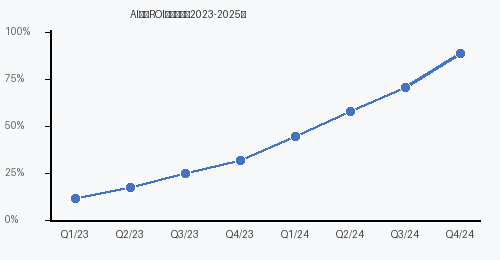

In [6]:
from langchain_core.documents import Document
from IPython.display import display, Image as IPyImage

def image_to_rag_document(img_meta: dict, vlm_description: str | None = None) -> Document:
    """
    将图片元数据转换为 LangChain Document，供 RAG 索引。

    索引策略选项（按能力递增）：
    A. 仅元数据  ── 只记录位置/尺寸，不参与语义检索（当前实现）
    B. VLM描述  ── 接入 GPT-4V / LLaVA / Qwen-VL 生成图片描述文本
    C. OCR图片  ── 图片含文字时用 OCR 提取（见 Step 6）

    Parameters
    ----------
    img_meta       : extract_images_from_pdf 返回的单张图片字典
    vlm_description: 如已通过 VLM 生成描述，可直接传入
    """
    w, h = img_meta["width"], img_meta["height"]
    aspect = w / h if h > 0 else 1

    # 根据宽高比简单推断图片类型
    if aspect > 2.5:
        img_type = "横幅/宽图表（如折线图/柱状图）"
    elif 0.8 <= aspect <= 1.3:
        img_type = "正方形图（如饼图/流程图）"
    else:
        img_type = "矩形图（如截图/架构图）"

    description = vlm_description or (
        f"[图片] 来源：第{img_meta['page']+1}页，文件名：{img_meta['filename']}。"
        f"尺寸：{w}×{h}px，格式：{img_meta['format']}，推测类型：{img_type}。"
        f"如需语义检索，请接入 VLM（如 GPT-4V/LLaVA）生成详细描述后替换本文本。"
    )

    return Document(
        page_content=description,
        metadata={
            "source":       img_meta["path"],
            "page":         img_meta["page"],
            "content_type": "image",
            "img_width":    w,
            "img_height":   h,
            "img_format":   img_meta["format"],
            "img_filename": img_meta["filename"],
        }
    )

# 为每张图片创建 Document
image_docs = [image_to_rag_document(m) for m in images_meta]

print(f"共创建 {len(image_docs)} 个图片 Document")
print()
for doc in image_docs:
    print(f"  内容: {doc.page_content[:100]}")
    print(f"  元数据: {doc.metadata}")
    print()

# Jupyter 内联预览第一张图片
if images_meta:
    print(f"图片预览：{images_meta[0]['filename']}")
    display(IPyImage(filename=images_meta[0]["path"], width=450))


## Step 5：表格提取 — pdfplumber 智能表格识别

`pdfplumber` 通过分析 PDF 页面上的 **线条和边框** 来定位表格边界，然后将单元格内容提取为二维列表。  
提取完成后转换为 **Markdown 格式**，整体作为一个 chunk 写入向量库（不切分，保留结构完整性）。


In [7]:
import pdfplumber

def table_to_markdown(table: list[list]) -> str:
    """将二维列表转换为 Markdown 表格字符串"""
    if not table:
        return ""
    # 确保每行列数一致
    ncols = max(len(row) for row in table)
    rows = [list(row) + [""] * (ncols - len(row)) for row in table]
    # 计算每列最大宽度
    col_w = [max(len(str(rows[r][c])) for r in range(len(rows))) for c in range(ncols)]

    lines = []
    for ri, row in enumerate(rows):
        cells = [str(row[c]).ljust(col_w[c]) for c in range(ncols)]
        lines.append("| " + " | ".join(cells) + " |")
        if ri == 0:   # 标题行后添加分隔线
            lines.append("| " + " | ".join("-" * w for w in col_w) + " |")
    return "\n".join(lines)


def extract_tables_from_pdf(pdf_path: str) -> list[dict]:
    """
    使用 pdfplumber 逐页提取表格：
    - vertical_strategy / horizontal_strategy: 基于线条检测单元格边界
    - snap_tolerance: 线条对齐容差（像素）
    返回列表，每项包含 page / raw / markdown / rows / cols。
    """
    all_tables = []

    with pdfplumber.open(pdf_path) as pdf:
        for page_num, page in enumerate(pdf.pages):
            tables = page.extract_tables({
                "vertical_strategy":   "lines",
                "horizontal_strategy": "lines",
                "snap_tolerance":      3,
                "join_tolerance":      3,
            })

            for t_idx, table in enumerate(tables):
                if not table or len(table) < 2:
                    continue
                # 清洗单元格（去换行、去首尾空白）
                cleaned = [
                    [(cell.replace("\n", " ").strip() if cell else "") for cell in row]
                    for row in table
                ]
                md = table_to_markdown(cleaned)
                all_tables.append({
                    "page":      page_num,
                    "table_idx": t_idx,
                    "rows":      len(cleaned),
                    "cols":      len(cleaned[0]) if cleaned else 0,
                    "raw":       cleaned,
                    "markdown":  md,
                })
                header = "、".join(c for c in cleaned[0] if c)
                print(f"  ✓ 第{page_num+1}页 表格{t_idx+1}  "
                      f"{len(cleaned)}行×{len(cleaned[0])}列  列名: [{header}]")

    print(f"\n共检测到 {len(all_tables)} 个表格")
    return all_tables


print("开始提取表格...")
tables_data = extract_tables_from_pdf(PDF_PATH)

# 展示第一个表格的 Markdown 格式
if tables_data:
    print("\n── 第一个表格（Markdown 格式）──────────────────────────────")
    print(tables_data[0]["markdown"])


开始提取表格...
  ✓ 第2页 表格1  6行×5列  列名: [nnn、nnnn、nnnn、nn、nnnn]
  ✓ 第3页 表格1  5行×6列  列名: [nn、nnnn、nnnnn、nnnn、nnn、nnnn]

共检测到 2 个表格

── 第一个表格（Markdown 格式）──────────────────────────────
| nnn      | nnnn         | nnnn | nn    | nnnn   |
| -------- | ------------ | ---- | ----- | ------ |
| Chroma   | nn/nn        | nnn  | <10ms | nn/nn  |
| Weaviate | nnn          | nnn  | <20ms | nnnn   |
| Pinecone | nnnSaaS      | nn   | <50ms | nnnn   |
| Milvus   | nnnnn        | nnn  | <30ms | nnnn   |
| pgvector | PostgreSQLnn | nnn  | <15ms | nnPGnn |


In [8]:
def tables_to_documents(tables_data: list[dict], source_path: str) -> list[Document]:
    """将 pdfplumber 提取的表格列表转换为 LangChain Document（整体保留，不切分）"""
    table_docs = []
    for t in tables_data:
        header_desc = "、".join(c for c in t["raw"][0] if c) if t["raw"] else ""
        content = (
            f"[数据表格] 第{t['page']+1}页，共{t['rows']}行×{t['cols']}列。\n"
            f"列名：{header_desc}\n\n"
            f"{t['markdown']}"
        )
        doc = Document(
            page_content=content,
            metadata={
                "source":       source_path,
                "page":         t["page"],
                "content_type": "table",
                "table_idx":    t["table_idx"],
                "rows":         t["rows"],
                "cols":         t["cols"],
            }
        )
        table_docs.append(doc)

    print(f"共创建 {len(table_docs)} 个表格 Document")
    for doc in table_docs:
        print(f"\n  第{doc.metadata['page']+1}页 表格{doc.metadata['table_idx']+1}:")
        print(f"  {doc.page_content[:200]}")
    return table_docs

table_docs = tables_to_documents(tables_data, PDF_PATH)


共创建 2 个表格 Document

  第2页 表格1:
  [数据表格] 第2页，共6行×5列。
列名：nnn、nnnn、nnnn、nn、nnnn

| nnn      | nnnn         | nnnn | nn    | nnnn   |
| -------- | ------------ | ---- | ----- | ------ |
| Chroma   | nn/nn        | nnn  | <10ms | nn/nn  |

  第3页 表格1:
  [数据表格] 第3页，共5行×6列。
列名：nn、nnnn、nnnnn、nnnn、nnn、nnnn

| nn      | nnnn   | nnnnn   | nnnn   | nnn    | nnnn     |
| ------- | ------ | ------- | ------ | ------ | -------- |
| Phase 1 | 0–3nn  | N/Annnn 


## Step 6：OCR 处理 — 扫描版 PDF 的文字识别

当 PDF 页面是**扫描图片**（无文字层）时，需要先将页面渲染为图像，再用 OCR 提取文字。

| 工具 | 安装 | 中文支持 | 说明 |
|-----|------|---------|------|
| **easyocr** | `pip install easyocr` | ✓ | 纯 Python，无需额外二进制 |
| **pytesseract** | `pip install pytesseract` + 安装 Tesseract 二进制 | ✓（需语言包） | 经典方案 |
| **百度/阿里 OCR API** | SDK | ✓ | 云端，高精度，需联网 |

本节演示：① 自动检测扫描页，② 用 `easyocr` 进行 OCR（需先 `pip install easyocr`）。


In [9]:
import fitz
import numpy as np

# ── 6a. 扫描件自动检测 ────────────────────────────────────────────
def detect_scanned_pages(pdf_path: str, text_threshold: int = 50) -> list[int]:
    """
    判断哪些页面是扫描件：
    逻辑：提取的文字字符数 < text_threshold，且页面含嵌入图片 → 疑似扫描件。
    """
    doc = fitz.open(pdf_path)
    scanned = []
    print(f"{'页码':>4}  {'字符数':>6}  {'图片数':>6}  状态")
    print("─" * 40)
    for page_num, page in enumerate(doc):
        text   = page.get_text("text").strip()
        images = page.get_images(full=True)
        n_chars = len(text)
        is_scan = (n_chars < text_threshold) and (len(images) > 0)
        status  = "⚠️ 疑似扫描件" if is_scan else "✅ 文字PDF"
        print(f"  {page_num+1:2d}  {n_chars:6d}  {len(images):6d}  {status}")
        if is_scan:
            scanned.append(page_num)
    doc.close()
    print(f"\n发现 {len(scanned)} 页扫描件：{[p+1 for p in scanned]}")
    return scanned

scanned_pages = detect_scanned_pages(PDF_PATH)

# ── 6b. easyocr OCR（取消注释后使用）────────────────────────────
# 注意：首次运行会下载约 40MB 的语言模型
#
# %pip install -q easyocr
# import easyocr
#
# ocr_reader = easyocr.Reader(['ch_sim', 'en'], gpu=False)  # 中英混合
#
# def ocr_page_to_document(pdf_path: str, page_num: int, dpi: int = 200) -> Document:
#     """将 PDF 指定页渲染为图片后做 OCR，返回 Document"""
#     doc = fitz.open(pdf_path)
#     page = doc[page_num]
#     mat = fitz.Matrix(dpi / 72, dpi / 72)     # 72pt → dpi 分辨率
#     pix = page.get_pixmap(matrix=mat, alpha=False)
#     img_array = np.frombuffer(pix.samples, dtype=np.uint8)
#     img_array = img_array.reshape(pix.height, pix.width, pix.n)
#     doc.close()
#
#     results  = ocr_reader.readtext(img_array)
#     ocr_text = "\n".join(text for (_, text, conf) in results if conf > 0.4)
#
#     return Document(
#         page_content=ocr_text,
#         metadata={
#             "source":       pdf_path,
#             "page":         page_num,
#             "content_type": "ocr_text",
#             "ocr_engine":   "easyocr",
#             "ocr_dpi":      dpi,
#         }
#     )
#
# ocr_docs = [ocr_page_to_document(PDF_PATH, p) for p in scanned_pages]
# print(f"OCR 完成，生成 {len(ocr_docs)} 个 Document")

# ── 6c. pytesseract 方案（Windows 需先安装 Tesseract 二进制）────
# 下载：https://github.com/UB-Mannheim/tesseract/wiki
# 中文语言包：tessdata/chi_sim.traineddata
#
# import pytesseract
# from PIL import Image as PILImage
# pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
#
# def ocr_with_tesseract(pdf_path: str, page_num: int, lang: str = "chi_sim+eng") -> str:
#     doc  = fitz.open(pdf_path)
#     page = doc[page_num]
#     pix  = page.get_pixmap(matrix=fitz.Matrix(200/72, 200/72))
#     img  = PILImage.frombytes("RGB", [pix.width, pix.height], pix.samples)
#     text = pytesseract.image_to_string(img, lang=lang)
#     doc.close()
#     return text

print("\n（本 PDF 为文字型，无需 OCR）")


  页码     字符数     图片数  状态
────────────────────────────────────────
   1     191       1  ✅ 文字PDF
   2     338       1  ✅ 文字PDF
   3     420       0  ✅ 文字PDF
   4     212       0  ✅ 文字PDF
   5     228       0  ✅ 文字PDF

发现 0 页扫描件：[]

（本 PDF 为文字型，无需 OCR）


## Step 7：多模态内容统一处理管道

将前面各步骤整合成一个函数，输入 PDF 路径，输出带 `content_type` 元数据标签的全量 Document 列表。


In [10]:
import fitz
from langchain_core.documents import Document

def build_multimodal_pipeline(pdf_path: str) -> list[Document]:
    """
    多模态 PDF → Document 统一管道
    处理顺序：
      1. PyMuPDF 深度文本提取（保留标题层级）
      2. PyMuPDF 图片提取 + 元数据 Document
      3. pdfplumber 表格提取 + Markdown Document
      4. 扫描件检测（可接入 OCR）
    所有 Document 统一标记 content_type 元数据。
    """
    print("=" * 60)
    print("  多模态 PDF 处理管道")
    print("=" * 60)
    all_docs: list[Document] = []

    # ── 步骤 1：深度文本提取 ──────────────────────────────────
    print("\n[1/4] 深度文本提取（PyMuPDF）...")
    fitz_doc = fitz.open(pdf_path)
    text_docs = []
    for page_num, page in enumerate(fitz_doc):
        text = page.get_text("text").strip()
        if text:
            text_docs.append(Document(
                page_content=text,
                metadata={
                    "source":       pdf_path,
                    "page":         page_num,
                    "content_type": "text",
                }
            ))
    fitz_doc.close()
    all_docs.extend(text_docs)
    print(f"  → {len(text_docs)} 页文字内容")

    # ── 步骤 2：图片提取 ─────────────────────────────────────
    print("\n[2/4] 图片提取（PyMuPDF）...")
    imgs = extract_images_from_pdf(pdf_path)
    img_docs = [image_to_rag_document(m) for m in imgs]
    all_docs.extend(img_docs)
    print(f"  → {len(img_docs)} 张图片")

    # ── 步骤 3：表格提取 ─────────────────────────────────────
    print("\n[3/4] 表格提取（pdfplumber）...")
    tables = extract_tables_from_pdf(pdf_path)
    t_docs = tables_to_documents(tables, pdf_path)
    all_docs.extend(t_docs)
    print(f"  → {len(t_docs)} 个表格")

    # ── 步骤 4：扫描件检测 ───────────────────────────────────
    print("\n[4/4] 扫描件检测...")
    scanned = detect_scanned_pages(pdf_path)
    if scanned:
        print(f"  → 发现 {len(scanned)} 页扫描件（第{[p+1 for p in scanned]}页）")
        print("    建议：接入 easyocr/pytesseract 后调用 ocr_page_to_document() 补充")
    else:
        print("  → 未检测到扫描件")

    # ── 汇总统计 ─────────────────────────────────────────────
    print("\n" + "=" * 60)
    type_counts: dict[str, int] = {}
    for d in all_docs:
        ct = d.metadata.get("content_type", "unknown")
        type_counts[ct] = type_counts.get(ct, 0) + 1

    print("  多模态处理结果：")
    for ct, cnt in type_counts.items():
        bar = "█" * cnt
        print(f"    {ct:12s}: {cnt:3d}  {bar}")
    print(f"    {'合计':12s}: {len(all_docs):3d}")
    print("=" * 60)
    return all_docs

all_docs = build_multimodal_pipeline(PDF_PATH)


  多模态 PDF 处理管道

[1/4] 深度文本提取（PyMuPDF）...
  → 5 页文字内容

[2/4] 图片提取（PyMuPDF）...
  ✓ 第1页 图1  page01_img01.png  (500×260px, 5.6KB, png)
  ✓ 第2页 图1  page02_img01.png  (520×160px, 3.5KB, png)

共提取 2 张图片 → 保存至 ./pdf_extracted_images/
  → 2 张图片

[3/4] 表格提取（pdfplumber）...
  ✓ 第2页 表格1  6行×5列  列名: [nnn、nnnn、nnnn、nn、nnnn]
  ✓ 第3页 表格1  5行×6列  列名: [nn、nnnn、nnnnn、nnnn、nnn、nnnn]

共检测到 2 个表格
共创建 2 个表格 Document

  第2页 表格1:
  [数据表格] 第2页，共6行×5列。
列名：nnn、nnnn、nnnn、nn、nnnn

| nnn      | nnnn         | nnnn | nn    | nnnn   |
| -------- | ------------ | ---- | ----- | ------ |
| Chroma   | nn/nn        | nnn  | <10ms | nn/nn  |

  第3页 表格1:
  [数据表格] 第3页，共5行×6列。
列名：nn、nnnn、nnnnn、nnnn、nnn、nnnn

| nn      | nnnn   | nnnnn   | nnnn   | nnn    | nnnn     |
| ------- | ------ | ------- | ------ | ------ | -------- |
| Phase 1 | 0–3nn  | N/Annnn 
  → 2 个表格

[4/4] 扫描件检测...
  页码     字符数     图片数  状态
────────────────────────────────────────
   1     191       1  ✅ 文字PDF
   2     338       1  ✅ 文字PDF
   3     420       0  

## Step 7b：三模态内容分类提取 & 合并

`build_multimodal_pipeline` 内部已完成提取，这一步将结果**按类型拆分展示**，再显式合并成统一的 `all_docs`，让数据流完全透明。

```
all_docs
├── text_docs   ← PyMuPDF 深度文本（带标题层级）
├── table_docs  ← pdfplumber 表格（Markdown 格式，整体保留）
└── image_docs  ← PyMuPDF 图片（元数据占位，待 OCR / 视觉模型描述）
```

三类 Document 的 `content_type` 元数据分别为 `"text"` / `"table"` / `"image"`，后续分块和向量库写入均依赖此字段。

In [ ]:
from collections import Counter

# ── 1. 按 content_type 拆分（管道已提取，此处显式分类）─────────
text_docs  = [d for d in all_docs if d.metadata.get("content_type") == "text"]
table_docs = [d for d in all_docs if d.metadata.get("content_type") == "table"]
image_docs = [d for d in all_docs if d.metadata.get("content_type") == "image"]
ocr_docs   = [d for d in all_docs if d.metadata.get("content_type") == "ocr_text"]

print("─" * 55)
print("  三模态提取结果明细")
print("─" * 55)
print(f"  📄 文字 (text)    : {len(text_docs):3d} 个 Document")
print(f"  📊 表格 (table)   : {len(table_docs):3d} 个 Document")
print(f"  🖼  图片 (image)   : {len(image_docs):3d} 个 Document")
if ocr_docs:
    print(f"  🔍 OCR  (ocr_text): {len(ocr_docs):3d} 个 Document")
print("─" * 55)

# ── 2. 显式合并 ────────────────────────────────────────────────
all_docs = text_docs + table_docs + image_docs + ocr_docs
print(f"  合并后总计        : {len(all_docs):3d} 个 Document")
print("─" * 55)

# ── 3. 各类型示例 ──────────────────────────────────────────────
for label, docs in [("文字", text_docs), ("表格", table_docs), ("图片", image_docs)]:
    if docs:
        sample = docs[0]
        page   = sample.metadata.get("page", "?")
        print(f"\n── {label} 示例（第{int(page)+1}页）──")
        print(f"   元数据: {sample.metadata}")
        print(f"   内容  : {sample.page_content[:200]}")

# ── 4. 按页分布热力图（ASCII）─────────────────────────────────
page_type_map: dict[int, list[str]] = {}
for d in all_docs:
    p  = int(d.metadata.get("page", -1))
    ct = d.metadata.get("content_type", "?")[0].upper()  # T / A / I / O
    page_type_map.setdefault(p, []).append(ct)

print("\n── 各页内容分布 ──────────────────────────────────────────")
print(f"  {'页码':>4}  内容")
for pg in sorted(page_type_map):
    tags = " ".join(sorted(page_type_map[pg]))
    print(f"  第{pg+1:2d}页  {tags}")


## Step 8：多模态分块策略

不同内容类型使用不同的分块策略：

| content_type | 分块策略 | 原因 |
|-------------|---------|------|
| `text` | `RecursiveCharacterTextSplitter`（chunk=800, overlap=150） | 普通文本需切分保证检索粒度 |
| `table` | **不切分**，整体作为一个 chunk | 切分会破坏表格行列对应关系 |
| `image` | **不切分**，描述文本整体作为一个 chunk | 描述已足够简短 |
| `ocr_text` | 同 `text` | OCR 后按普通文本处理 |


In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# 文字内容使用标准分块器
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1500,
    chunk_overlap=200,
    # 中英文混合：优先按语义边界（段落 > 句子 > 词）分割
    separators=["\n\n", "\n", "。", "！", "？", ".", "!", "?", " ", ""],
    length_function=len,
    add_start_index=True,   # 元数据记录 chunk 在原文的起始位置
)

final_chunks = []
for doc in all_docs:
    ct = doc.metadata.get("content_type", "text")

    if ct in ("text", "ocr_text"):
        # 文字型：正常分块
        sub = text_splitter.split_documents([doc])
        final_chunks.extend(sub)

    elif ct == "table":
        # 表格：整体保留，不切分（防止破坏行列结构）
        final_chunks.append(doc)

    elif ct == "image":
        # 图片描述：整体保留
        final_chunks.append(doc)

# ── 统计分块结果 ────────────────────────────────────────────────
type_stats: dict[str, int] = {}
for chunk in final_chunks:
    ct = chunk.metadata.get("content_type", "unknown")
    type_stats[ct] = type_stats.get(ct, 0) + 1

print(f"原始 Document 数: {len(all_docs)}")
print(f"分块后 chunk  数: {len(final_chunks)}")
print()
print(f"{'content_type':14s}  {'chunks':>6}")
print("─" * 25)
for ct, n in type_stats.items():
    print(f"{ct:14s}  {n:6d}")

# 各类型 chunk 示例
print("\n── 各类型 chunk 示例 ─────────────────────────────────────")
shown: set[str] = set()
for chunk in final_chunks:
    ct = chunk.metadata.get("content_type", "unknown")
    if ct not in shown:
        print(f"\n[{ct}]")
        print(f"  元数据: {chunk.metadata}")
        print(f"  内容  : {chunk.page_content[:280]}")
        shown.add(ct)
    if len(shown) >= 3:
        break


原始 Document 数: 9
分块后 chunk  数: 9

content_type    chunks
─────────────────────────
text                 5
image                2
table                2

── 各类型 chunk 示例 ─────────────────────────────────────

[text]
  元数据: {'source': 'sample_multimodal.pdf', 'page': 0, 'content_type': 'text', 'start_index': 0}
  内容  : IIAIIIII 2025
IIII
IIIIIIIIII2025-2030IIIIIIIIIIIIIIIIIIILLMI+IIIIIIIRAGIIIIIIIIIIIAI
IIIIIAIIIIIIIIIIIIROIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII
IIIIIIIIIII
I1IAIIIROIIIIII2023–2025IIIII

[image]
  元数据: {'source': './pdf_extracted_images\\page01_img01.png', 'page': 0, 'content_type': 'image', 'img_width': 500, 'img_height': 260, 'img_format': 'png', 'img_filename': 'page01_img01.png'}
  内容  : [图片] 来源：第1页，文件名：page01_img01.png。尺寸：500×260px，格式：png，推测类型：矩形图（如截图/架构图）。如需语义检索，请接入 VLM（如 GPT-4V/LLaVA）生成详细描述后替换本文本。

[table]
  元数据: {'source': 'sample_multimodal.pdf', 'page': 1, 'content_type': 'table', 'table_idx': 0, 'rows': 6, 'cols': 5}
  内容  : [数据表格] 第2页，共6行×5列。
列名：nnn、nnnn、

## Step 9：向量嵌入 + 存入 Milvus Lite

`pymilvus 2.4.x` 引入了 **Milvus Lite**——只需将 `uri` 指向一个本地 `.db` 文件，即可在无服务进程的情况下使用完整的 Milvus 功能（ANN索引、标量过滤、Collection 管理）。  
`content_type` 元数据随 chunk 持久化，检索时通过 **`expr` 字符串表达式**按类型过滤。


In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_milvus import Milvus

# Milvus Lite：本地文件存储，无需启动 milvus 服务进程
MILVUS_URI  = "./milvus_rag.db"
COLLECTION  = "rag_multimodal_pdf"

print("正在加载嵌入模型（首次运行会下载模型文件）...")
embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-m3",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)
print("嵌入模型加载完成")

print(f"\n正在向量化 {len(final_chunks)} 个多模态 chunk 并写入 Milvus Lite...")
vectorstore = Milvus.from_documents(
    documents=final_chunks,
    embedding=embeddings,
    collection_name=COLLECTION,
    connection_args={"uri": MILVUS_URI},
    drop_old=True,      # 重新建表，避免重复写入
)
print(f"写入完成！Collection: {COLLECTION}")
print(f"存储路径 : {MILVUS_URI}")

# 用 pymilvus MilvusClient 查询入库统计
from pymilvus import MilvusClient
from collections import Counter

mc = MilvusClient(MILVUS_URI)
total = mc.get_collection_stats(COLLECTION)["row_count"]
print(f"向量数量 : {total}")

# 按 content_type 统计
rows = mc.query(
    collection_name=COLLECTION,
    filter="",
    output_fields=["content_type"],
    limit=total + 1,
)
ct_counts = Counter(r.get("content_type", "unknown") for r in rows)
print("\n入库类型分布:")
for ct, n in ct_counts.items():
    print(f"  {ct:14s}: {n}")


ModuleNotFoundError: No module named 'packaging.markers'

: 

## Step 10：基础向量检索测试（支持按 content_type 过滤）


In [ ]:
def retrieve(query: str, k: int = 3, content_type: str | None = None):
    """
    向量相似度检索，支持按 content_type 过滤。
    Milvus 用 expr 字符串表达式过滤（非 Chroma 的 where dict）。
    content_type: None（不过滤）| "text" | "table" | "image"
    """
    # Milvus 过滤语法：布尔表达式字符串
    expr = f'content_type == "{content_type}"' if content_type else None
    kwargs = {"expr": expr} if expr else {}

    results = vectorstore.similarity_search_with_score(query, k=k, **kwargs)
    type_label = f"（仅 {content_type}）" if content_type else "（全类型）"
    print(f"查询{type_label}: {query!r}")
    print("─" * 65)
    for rank, (doc, score) in enumerate(results, 1):
        ct       = doc.metadata.get("content_type", "?")
        page_num = doc.metadata.get("page", "?")
        # Milvus 返回 L2 距离（越小越近），Chroma 返回余弦相似度（越大越近）
        print(f"[{rank}] L2距离: {score:.4f} | 类型: {ct:6s} | 第{int(page_num)+1}页")
        print(f"    {doc.page_content[:220]}")
        print()

# 全类型检索
retrieve("向量数据库对比")


查询: 'RAG系统的离线索引和在线检索流程是什么'
────────────────────────────────────────────────────────────
[1] 相似度分数: 1.4259 | 第5页 | sample_10pages.pdf
    ■■■ ■■■■■■■■
■■■■■■■■■■■■■■■■■■
 all-MiniLM-L6-v2■■■■384■■■■■■■■■■■■■
 text2vec-large-chinese■■■■■■■■■■■■■■■
 OpenAI text-embedding-3-large■1536■■■■■■■■API■■■
 BGE-M3■■■■■■■■■■■■■■■
■■■■■■■■BGE■■■

[2] 相似度分数: 1.4410 | 第3页 | sample_10pages.pdf
    ■■■ RAG■■■■■■
RAG■■■■■■■■■■■■■■■■■■■■■■■■■■
■■■■■■■■■■PDF/Word/HTML■→ ■■■■■Chunking■→ ■■■■■Embedding■→ ■■■■■■■■
■■■■■■■■■ → ■■■■■Top-K■→ Cross-Encoder■■ → ■■Prompt → LLM■■■■■
■■■■■■■■Chroma■■■■■■■Weav

[3] 相似度分数: 1.5058 | 第10页 | sample_10pages.pdf
    ■■■■■
RAG■■■■■■■■AI■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
■■■■■■■■■■■■■■■■■
■■■■■■■■RAG■■■■■■■■■■■■■■■■■■■■■Agent+RAG■■■■■■■■■■■■■■■■■■■■■
■■■■■■■■■■■■■■■■■■■■■RAG■■■■■■■■■■



In [ ]:
# 只检索表格类内容（Milvus expr 过滤）
retrieve("各阶段KPI目标和检索准确率", content_type="table")


查询: '金融机构数据安全合规要求'
────────────────────────────────────────────────────────────
[1] 相似度分数: 1.6236 | 第6页 | sample_10pages.pdf
    ■■■ ■■■■■■■
■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
■■1 - ■■■■Chroma■■■■■ Top-20■■■■■■
■■2 - ■■■Cross-Encoder■query■■■■■chunk■■■■■■Top-3■■■
■■■■■Hybrid Search■■■■■■ + BM25■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■


[2] 相似度分数: 1.6454 | 第4页 | sample_10pages.pdf
    ■■■ PDF■■■■■■■■
■■■■■■■■■■■■PDF■■■■■■■■■■■■■■■■■■■■■■■■■■PDF■■■■■■
1. ■■■■■■■■■■PDF■■■■■■OCR■■
2. ■■■■■■■■■■■■■■■■■■■■■■■■■■■
3. ■■■■■■■chunk_size=800, overlap=150■■■■■■■■■■
4. ■■■■■■■■chunk■■■■■■■■■■

[3] 相似度分数: 1.6610 | 第8页 | sample_10pages.pdf
    ■■■ ■■■■■■
1. ■■■■■■■■■■■RAG■■■■■■■■■■■■■■■■■■■■■■■■LLM■■40%■
2. ■■■■■■■■■■■■■■RAG■■■■■■■■■■■■■■■■■
3. ■■■■■■■■■■■■■■■■PDF■■■■■■■■■■■■■■
4. ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
5. ■■IT■■■■■■■■■■IT■■■■■■



In [ ]:
# 只检索图片类内容（Milvus expr 过滤）
retrieve("ROI趋势图架构图", content_type="image")


查询: '智能客服和合规审查的应用'
────────────────────────────────────────────────────────────
[1] 相似度分数: 1.8450 | 第5页 | sample_10pages.pdf
    ■■■ ■■■■■■■■
■■■■■■■■■■■■■■■■■■
 all-MiniLM-L6-v2■■■■384■■■■■■■■■■■■■
 text2vec-large-chinese■■■■■■■■■■■■■■■
 OpenAI text-embedding-3-large■1536■■■■■■■■API■■■
 BGE-M3■■■■■■■■■■■■■■■
■■■■■■■■BGE■■■

[2] 相似度分数: 1.9368 | 第3页 | sample_10pages.pdf
    ■■■ RAG■■■■■■
RAG■■■■■■■■■■■■■■■■■■■■■■■■■■
■■■■■■■■■■PDF/Word/HTML■→ ■■■■■Chunking■→ ■■■■■Embedding■→ ■■■■■■■■
■■■■■■■■■ → ■■■■■Top-K■→ Cross-Encoder■■ → ■■Prompt → LLM■■■■■
■■■■■■■■Chroma■■■■■■■Weav

[3] 相似度分数: 1.9371 | 第1页 | sample_10pages.pdf
    ■■■■
■■■■■■■■■■2025-2030■■■■■■■■■■■■■■■■■■■LLM■+ ■■■■■■■RAG■■■■■■■■■■■A
I■■■■■AI■■■■■■■■■■■ROI■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
■■■■■■■■■■■■



## Step 11：Cross-Encoder 精排（双阶段检索）

第一阶段向量粗召回（Top-10），第二阶段 Cross-Encoder 对 `(query, chunk)` 对打分精排取 Top-3。


In [ ]:
from sentence_transformers import CrossEncoder

print("加载Cross-Encoder精排模型...")
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
print("精排模型加载完成")

def retrieve_and_rerank(query: str, recall_k: int = 10, final_k: int = 3):
    """双阶段检索：向量粗召回 → Cross-Encoder精排"""
    # 阶段1：向量粗召回
    candidates = vectorstore.similarity_search(query, k=recall_k)
    
    # 阶段2：Cross-Encoder精排
    pairs  = [(query, doc.page_content) for doc in candidates]
    scores = reranker.predict(pairs)
    ranked = sorted(zip(scores, candidates), key=lambda x: x[0], reverse=True)
    top    = ranked[:final_k]
    
    print(f"查询: {query!r}")
    print(f"粗召回: {len(candidates)} 个 → 精排后: {final_k} 个")
    print("─" * 60)
    for rank, (score, doc) in enumerate(top, 1):
        page_num = doc.metadata.get("page", "?") 
        print(f"[{rank}] 精排分数: {score:.4f} | 第{page_num+1}页")
        print(f"    {doc.page_content[:300]}")
        print()
    return [doc for _, doc in top]

# 测试精排效果
docs = retrieve_and_rerank("企业部署RAG系统需要注意哪些安全合规问题")

加载Cross-Encoder精排模型...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


精排模型加载完成
查询: '企业部署RAG系统需要注意哪些安全合规问题'
粗召回: 10 个 → 精排后: 3 个
────────────────────────────────────────────────────────────
[1] 精排分数: -2.9966 | 第3页
    ■■■ RAG■■■■■■
RAG■■■■■■■■■■■■■■■■■■■■■■■■■■
■■■■■■■■■■PDF/Word/HTML■→ ■■■■■Chunking■→ ■■■■■Embedding■→ ■■■■■■■■
■■■■■■■■■ → ■■■■■Top-K■→ Cross-Encoder■■ → ■■Prompt → LLM■■■■■
■■■■■■■■Chroma■■■■■■■Weaviate■■■■■■Pinecone■■■■■■

[2] 精排分数: -3.9597 | 第10页
    ■■■■■
RAG■■■■■■■■AI■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
■■■■■■■■■■■■■■■■■
■■■■■■■■RAG■■■■■■■■■■■■■■■■■■■■■Agent+RAG■■■■■■■■■■■■■■■■■■■■■
■■■■■■■■■■■■■■■■■■■■■RAG■■■■■■■■■■

[3] 精排分数: -6.9989 | 第2页
    ■■■ ■■■■■
■■■■■■■AI■■■■■■■■■■■GPT-4■Claude■Gemini■■■■■■■■■■■■■■■■■■■■■■■■■■■■
■■■■■■■■■■■Hallucination■■■■■■■■■■■■■■■RAG■Retrieval-Augmented
Generation■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■



## Step 12：知识库统计概览


In [ ]:
from pymilvus import MilvusClient
from collections import Counter

mc = MilvusClient(MILVUS_URI)

print("═" * 55)
print("  企业RAG知识库 — Milvus Lite 统计概览")
print("═" * 55)

# 列举所有 Collection
collections = mc.list_collections()
for col_name in collections:
    stats = mc.get_collection_stats(col_name)
    print(f"  Collection: {col_name:30s} | 向量数: {stats['row_count']}")

print("─" * 55)

# 查询所有元数据
total = mc.get_collection_stats(COLLECTION)["row_count"]
rows = mc.query(
    collection_name=COLLECTION,
    filter="",
    output_fields=["content_type", "page"],
    limit=total + 1,
)

# 按 content_type 分布
ct_counts = Counter(r.get("content_type", "unknown") for r in rows)
print("  各内容类型 chunk 数量:")
for ct, n in ct_counts.items():
    bar = "█" * n
    print(f"    {ct:14s}: {n:3d}  {bar}")

print("─" * 55)

# 按页面分布
page_counts = Counter(r.get("page", -1) for r in rows)
print("  各页 chunk 数量:")
for page_num in sorted(page_counts):
    print(f"    第 {int(page_num)+1:2d} 页 → {page_counts[page_num]} 个 chunk")

print("═" * 55)
mc.close()


══════════════════════════════════════════════════
  企业RAG知识库 — 统计概览
══════════════════════════════════════════════════
  Collection: langchain_knowledge            | 向量数: 47
  Collection: rag_pdf_docs                   | 向量数: 10
──────────────────────────────────────────────────
  PDF来源分布（各页chunk数量）:
    第  1 页 → 1 个chunk
    第  2 页 → 1 个chunk
    第  3 页 → 1 个chunk
    第  4 页 → 1 个chunk
    第  5 页 → 1 个chunk
    第  6 页 → 1 个chunk
    第  7 页 → 1 个chunk
    第  8 页 → 1 个chunk
    第  9 页 → 1 个chunk
    第 10 页 → 1 个chunk
══════════════════════════════════════════════════


## Step 13：合成阶段（Synthesis）— 检索 + LLM 生成最终答案

RAG 完整链路的最后一步：将精排后的 chunks 拼成 context，交给 LLM 生成自然语言答案。

```
用户问题
    ↓
向量粗召回（Top-10）
    ↓
Cross-Encoder 精排（Top-3）
    ↓
拼装 Prompt（system + context + question）
    ↓
LLM 生成（Claude / GPT / 本地模型）
    ↓
最终答案
```

支持两种后端：
| 后端 | 环境变量 | 说明 |
|------|----------|------|
| Anthropic Claude | `ANTHROPIC_API_KEY` | 推荐，效果最好 |
| OpenAI GPT | `OPENAI_API_KEY` | 通用备选 |

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

# ── Prompt 模板 ────────────────────────────────────────────────────────
SYSTEM_PROMPT = """你是一个企业内部知识库助手，专门回答关于公司PDF文档中的问题。
请严格基于提供的参考资料回答，不要编造信息。
如果参考资料中没有足够信息，请明确说明"根据现有文档无法回答"。
回答时请注明信息来自哪一页。"""

def build_context(chunks: list) -> str:
    """将精排后的 chunks 拼装成 LLM 可读的 context 字符串"""
    parts = []
    for i, doc in enumerate(chunks, 1):
        page_num = doc.metadata.get("page", "?")
        ct       = doc.metadata.get("content_type", "text")
        type_label = {"text": "文本", "table": "表格", "image": "图片描述"}.get(ct, ct)
        parts.append(
            f"【参考资料 {i}】（第{int(page_num)+1}页 · {type_label}）\n{doc.page_content}"
        )
    return "\n\n".join(parts)


def synthesize_with_claude(query: str, chunks: list) -> str:
    """调用 Claude API 基于检索结果生成答案（需要 ANTHROPIC_API_KEY）"""
    import anthropic
    context = build_context(chunks)
    client  = anthropic.Anthropic()
    message = client.messages.create(
        model="claude-opus-4-5",
        max_tokens=1024,
        system=SYSTEM_PROMPT,
        messages=[{
            "role": "user",
            "content": f"参考资料如下：\n\n{context}\n\n问题：{query}"
        }]
    )
    return message.content[0].text


def synthesize_with_openai(query: str, chunks: list) -> str:
    """调用 OpenAI API 基于检索结果生成答案（需要 OPENAI_API_KEY）"""
    from openai import OpenAI
    context = build_context(chunks)
    client  = OpenAI()
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": f"参考资料如下：\n\n{context}\n\n问题：{query}"}
        ],
        max_tokens=1024,
        temperature=0.2,
    )
    return response.choices[0].message.content


def rag_answer(query: str, recall_k: int = 10, final_k: int = 3) -> str:
    """
    完整 RAG 链路：
      向量粗召回 → Cross-Encoder 精排 → LLM 合成答案
    自动选择可用的 LLM 后端（Claude 优先，其次 OpenAI）。
    """
    # ① 检索 + 精排
    top_chunks = retrieve_and_rerank(query, recall_k=recall_k, final_k=final_k)

    # ② 合成
    print("\n── LLM 合成答案 ─────────────────────────────────────────")
    if os.getenv("ANTHROPIC_API_KEY"):
        print("使用后端: Claude")
        answer = synthesize_with_claude(query, top_chunks)
    elif os.getenv("OPENAI_API_KEY"):
        print("使用后端: OpenAI")
        answer = synthesize_with_openai(query, top_chunks)
    else:
        # 无 API Key 时直接拼接检索结果（演示用）
        print("⚠️  未设置 ANTHROPIC_API_KEY / OPENAI_API_KEY，返回原始检索结果")
        answer = build_context(top_chunks)

    print(f"\n问题: {query}")
    print("─" * 60)
    print(answer)
    print("─" * 60)
    return answer


# ── 测试完整 RAG 链路 ────────────────────────────────────────
answer = rag_answer("企业部署RAG系统需要注意哪些安全合规问题")

## 总结

### 运行环境

| 项目 | 版本 |
|------|------|
| Python | **3.11.9**（推荐；1.24.x pymupdf 有 Py3.11 预编译 wheel） |
| 虚拟环境 | `.venv`（由 Python 3.11.9 创建） |

### 技术栈版本（2024年4月–7月，全部锁定）

| 库 | 锁定版本 | 发布时间 | 用途 |
|----|---------|---------|------|
| `pymupdf` | **1.24.9** | 2024-07 | PDF深度解析、图片提取 |
| `pdfplumber` | 0.10.4 | 2024-04 | 表格识别与提取 |
| `pypdf` | 4.2.0 | 2024-04 | 基础PDF加载 |
| `Pillow` | 10.3.0 | 2024-04 | 测试图片生成 |
| `reportlab` | 4.1.0 | 2024-04 | 生成多模态测试PDF |
| `langchain` | **0.2.5** | 2024-06 | 核心框架（0.2.x 稳定里程碑） |
| `langchain-text-splitters` | **0.2.1** | 2024-05 | `RecursiveCharacterTextSplitter` |
| `langchain-community` | **0.2.5** | 2024-06 | `PyPDFLoader` 等社区集成 |
| `langchain-milvus` | **0.1.3** | 2024-07 | Milvus 官方 LangChain 集成 |
| `langchain-huggingface` | **0.0.3** | 2024-06 | `HuggingFaceEmbeddings` |
| `sentence-transformers` | **3.0.0** | 2024-07 | CrossEncoder 精排模型 |
| `pymilvus` | **2.4.4** | 2024-07 | Milvus Lite 本地文件模式 |

### pymupdf 与 Python 版本兼容性说明

| Python 版本 | pymupdf 1.24.x 安装结果 | 原因 |
|------------|----------------------|------|
| **3.11** ✅ | 直接安装预编译 wheel | pymupdf 1.24.x 发布时 Py3.11 已稳定，有官方 wheel |
| **3.12** ✅ | 直接安装预编译 wheel | 同上 |
| **3.13** ❌ | 尝试源码编译，缺少 VS / py.exe | Python 3.13 于 2024-10 发布，晚于 1.24.x，无 wheel |

### ChromaDB → Milvus Lite 关键迁移对照

| 项目 | ChromaDB 写法 | Milvus Lite 写法 |
|------|--------------|-----------------|
| 导入 | `from langchain_chroma import Chroma` | `from langchain_milvus import Milvus` |
| 连接参数 | `persist_directory="./chroma_db"` | `connection_args={"uri": "./milvus_rag.db"}` |
| 重建 | 无（自动追加） | `drop_old=True` |
| 过滤参数 | `filter={"content_type": "table"}` | `expr='content_type == "table"'` |
| 距离含义 | 余弦相似度（越大越近） | L2 距离（越小越近） |
| 统计接口 | `chromadb.PersistentClient` | `pymilvus.MilvusClient` |

### 完整多模态处理流程

| 步骤 | 组件 | 说明 |
|------|------|------|
| 内容类型检测 | `pymupdf 1.24.9` | 逐页统计文字块/图片，判断扫描件 |
| 深度文字提取 | `fitz.get_text("dict")` | 字号/粗体/坐标 → 推断 H1/H2/body 层级 |
| 图片提取 | `fitz.extract_image(xref)` | PNG/JPEG 原始字节，保存为文件 |
| 表格提取 | `pdfplumber 0.10.4` | 线条检测 → Markdown 整体 chunk |
| OCR | `easyocr` / `pytesseract` | 扫描件渲染 → OCR → 按文字处理 |
| 多模态分块 | `langchain-text-splitters 0.2.1` | text/ocr 切分；table/image 整体保留 |
| 向量化 | `langchain-huggingface 0.0.3` MiniLM | 本地，无需 API |
| 存储 | `langchain-milvus 0.1.3` + `pymilvus 2.4.4` | Milvus Lite 本地文件，含 `content_type` 元数据 |
| 粗召回 | `vectorstore.similarity_search(expr=...)` | Top-10，支持 expr 类型过滤 |
| 精排 | `sentence-transformers 3.0.0` CrossEncoder | 重新打分取 Top-3 |

**下一步**：将 `retrieve_and_rerank()` 集成到 `mcp_server.py`，让 Agent 能够查询多模态 PDF 知识库。
